In [ ]:
import sys
import pandas as pd

# Add src to path to enable imports
sys.path.insert(0, '/Users/mateo/Desktop/Lin3s/proyectos/Client_Segmentation/src')
from segmentaciones.LRFM_DEFI.input_management import DatasetMapper

In [14]:
data = pd.read_excel("../../../data/online+retail/Online_retail.xlsx")
data = data.dropna()
data.reset_index(inplace=True)
data.head(5)

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [15]:
data['total'] = data['Quantity']*data['UnitPrice']

In [16]:
mapper = DatasetMapper()
data_clean = mapper.transform(data)

Mapeo automático:
  id_usuario <- CustomerID (confianza: 1.00)
  total_pedido <- total (confianza: 1.00)
  fecha_pedido <- InvoiceDate (confianza: 0.90)
  id_pedido <- InvoiceNo (confianza: 0.84)


In [17]:
data_clean.head()

,id_usuario,total_pedido,fecha_pedido,id_pedido
0,17850.0,15.30,2010-12-01 08:26:00,536365
1,17850.0,20.34,2010-12-01 08:26:00,536365
2,17850.0,22.00,2010-12-01 08:26:00,536365
3,17850.0,20.34,2010-12-01 08:26:00,536365
4,17850.0,20.34,2010-12-01 08:26:00,536365


# EXTRACCIÓN DE MÉTRICAS:
1. RFM
2. LRFMS


In [18]:
fecha_max = data_clean['fecha_pedido'].max() + pd.Timedelta(days=1)

In [19]:
df_pedidos = data_clean.groupby(['id_pedido', 'id_usuario', 'fecha_pedido'])['total_pedido'].sum().reset_index()
df_pedidos.head(5)

,id_pedido,id_usuario,fecha_pedido,total_pedido
0,536365,17850.0,2010-12-01 08:26:00,139.12
1,536366,17850.0,2010-12-01 08:28:00,22.20
2,536367,13047.0,2010-12-01 08:34:00,278.73
3,536368,13047.0,2010-12-01 08:34:00,70.05
4,536369,13047.0,2010-12-01 08:35:00,17.85


In [20]:
rfm = df_pedidos.groupby('id_usuario').agg({
    'fecha_pedido': lambda x: (fecha_max-x.max()).days,
    'id_pedido':'count',
    'total_pedido':'sum'
})
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm = rfm[rfm['Monetary']>0]
rfm.head(5)

,Recency,Frequency,Monetary
id_usuario,,,
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40
12352.0,36,11,1545.41


In [27]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


rfm_log = rfm.copy()
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log[['Recency','Frequency','Monetary']])

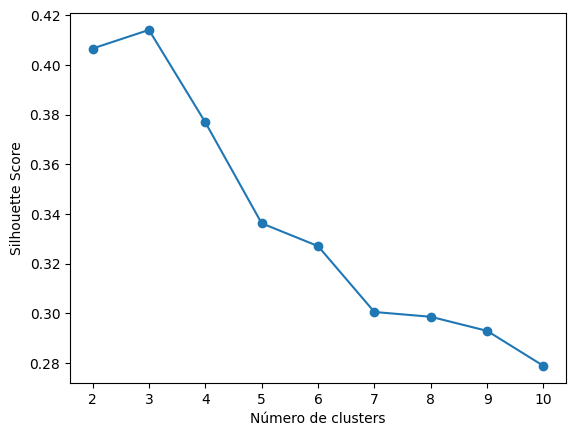

In [28]:
from sklearn.metrics import silhouette_score

sil_scores = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(rfm_scaled)
    sil_scores.append(silhouette_score(rfm_scaled, labels))

plt.plot(K, sil_scores, marker='o')
plt.xlabel('Número de clusters')
plt.ylabel('Silhouette Score')
plt.show()

best_k = K[sil_scores.index(max(sil_scores))]

kmeans = KMeans(n_clusters=best_k, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# SEGMENTACIÓN RFM

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. Preparar los datos
# Seleccionamos solo las columnas RFM
data_rfm = rfm[['Recency', 'Frequency', 'Monetary']]

# 2. Escalar los datos (StandardScaler hace que la media sea 0 y varianza 1)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(data_rfm)

# 3. Aplicar K-Means
# Supongamos que queremos 4 segmentos (ej: VIP, Fieles, En Riesgo, Perdidos)
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# 4. Analizar los resultados
# Esto te dirá el promedio de cada métrica por grupo
analisis_segmentos = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(1)

print(analisis_segmentos)

        Recency Frequency  Monetary      
           mean      mean      mean count
Cluster                                  
0          42.2       4.4    1332.6  3061
1         245.6       1.9     490.0  1055
2           5.1     110.2  124312.3    11
3          10.8      28.7   12238.9   192


In [26]:
rfm['R_rank'] = rfm['Recency'].rank(ascending=False)
rfm['F_rank'] = rfm['Frequency'].rank(ascending=True)
rfm['M_rank'] = rfm['Monetary'].rank(ascending=True)

rfm['R_rank_norm'] = (rfm['R_rank'] / rfm['R_rank'].max()) * 100
rfm['F_rank_norm'] = (rfm['F_rank'] / rfm['F_rank'].max()) * 100
rfm['M_rank_norm'] = (rfm['M_rank'] / rfm['M_rank'].max()) * 100

data_rfm = rfm.copy()
data_rfm.drop(columns=['R_rank', 'F_rank', 'M_rank'], inplace=True)
data_rfm.head()

,Recency,Frequency,Monetary,Cluster,R_rank_norm,F_rank_norm,M_rank_norm
id_usuario,,,,,,,
12347.0,2,7,4310.00,0,97.703304,81.176198,92.637185
12348.0,75,4,1797.24,0,37.719709,63.799491,77.355869
12349.0,19,1,1757.55,0,72.732599,14.829822,76.707571
12350.0,310,1,334.40,0,5.132412,14.829822,28.802964
12352.0,36,11,1545.41,0,57.440825,90.043992,73.859690
